##  **Automatic Image Captioning with Model Benchmarking and Robustness Analysis**

### **Part B: Studying Performance Change Under Image Occlusion**
#### **Section 1: Effect of Image Occlusion on SmolVLM**

This notebook tests the robustness of  SmolVLM (Zero-Shot) by occluding parts of the input image and observing the changes in captioning performance.

In [1]:
import os
import nltk
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from PIL import Image
from torch.utils.data import DataLoader
from transformers import ViTModel, AutoModelForCausalLM, AutoTokenizer, ViTImageProcessor
from transformers import AutoProcessor, AutoModelForVision2Seq
from torch.optim import AdamW
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader



In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/custom_captions_dataset.zip"
extract_to = "/content/custom_captions_dataset"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Unzipped to: {extract_to}")

Unzipped to: /content/custom_captions_dataset


#### **Dataloader**

In [ ]:
class CaptionsDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, img_folder, tokenizer=None, feature_extractor=None, processor=None, max_length=50, raw_mode=False):
        self.data = pd.read_csv(csv_file)
        self.img_folder = img_folder
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.raw_mode = raw_mode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_folder, self.data.iloc[idx]["filename"])
        caption = self.data.iloc[idx]["caption"]
        image = Image.open(img_path).convert("RGB")
        model_input = {}

        if self.raw_mode:
            return img_path, caption
        else:

            pixel_values = self.feature_extractor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)
            tokenized_caption = self.tokenizer(
                caption,
                padding="max_length",
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            )

            model_input["pixel_values"] = pixel_values
            model_input["input_ids"] = tokenized_caption.input_ids.squeeze(0)
            model_input["attention_mask"] = tokenized_caption.attention_mask.squeeze(0)

        model_input["caption"] = caption
        model_input["img_paths"] = img_path

        return model_input


In [ ]:
def collate_fn(batch):
    if isinstance(batch[0], tuple):  # raw_mode: (img_path, caption)
        img_paths, captions = zip(*batch)
        return {
            'img_paths': list(img_paths),
            'captions': list(captions)
        }

    # Training mode
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    captions = [item['caption'] for item in batch]
    img_paths = [item['img_paths'] for item in batch]

    return {
        'pixel_values': pixel_values,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'captions': captions,
        'img_paths': img_paths
    }


In [ ]:

def get_captioning_loaders(
    root_dir='dataset/custom_captions_dataset',
    train_dir='train',
    val_dir='val',
    test_dir='test',
    train_csv='train.csv',
    val_csv='val.csv',
    test_csv='test.csv',
    batch_size=8,
    collate_fn=None,
    use_processor=False,
    tokenizer_model_id="gpt2",
    extractor_model_id="google/vit-base-patch16-224-in21k"
):
    """
    Returns train, val, test dataloaders for both zero-shot (SmolVLM) and trainable ViT+Decoder model setup.
    """

    if use_processor:
        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                raw_mode=True
            )

    else:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_model_id)
        feature_extractor = ViTImageProcessor.from_pretrained(extractor_model_id)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                tokenizer=tokenizer,
                feature_extractor=feature_extractor
            )

    # Build paths
    train_path = f"{root_dir}/{train_dir}"
    val_path = f"{root_dir}/{val_dir}"
    test_path = f"{root_dir}/{test_dir}"
    train_csv_path = f"{root_dir}/{train_csv}"
    val_csv_path = f"{root_dir}/{val_csv}"
    test_csv_path = f"{root_dir}/{test_csv}"

    # Create datasets
    train_dataset = dataset_factory(train_csv_path, train_path)
    val_dataset = dataset_factory(val_csv_path, val_path)
    test_dataset = dataset_factory(test_csv_path, test_path)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader, test_loader


#### **Generate Occluded Images**

Image occlusion involves dividing the image into patches and masking a percentage of them with black pixels to test model robustness.

- **Patch-based Masking**: The image is divided into a grid of patches, and a specified percentage of these patches are masked (set to black).
- **Varying Occlusion Levels**: The percentage of masked patches is varied to simulate different levels of visual obstruction.
- **Robustness Testing**: By observing how the model's performance changes with increasing occlusion, we can assess its robustness to partial data loss.

In [ ]:
train_loader, val_loader, test_loader = get_captioning_loaders(
    root_dir='/kaggle/input/captioning',
    use_processor = True,
    batch_size=1
)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

In [ ]:
def generate_caption(image_np, model, feature_extractor, device):
    image_pil = Image.fromarray(image_np).convert("RGB")
    pixel_values = feature_extractor(images=image_pil, return_tensors="pt").pixel_values.to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        captions = model.generate(pixel_values)

    return captions[0]

def occlude_image(image: np.array, mask_percentage: int) -> np.array:
    height, width, channels = image.shape
    patch_size = 16

    num_patches_y = height // patch_size
    num_patches_x = width // patch_size
    total_patches = num_patches_y * num_patches_x

    num_mask = int((mask_percentage / 100.0) * total_patches)

    patch_indices = [(i, j) for i in range(num_patches_y) for j in range(num_patches_x)]
    selected_indices = np.random.choice(len(patch_indices), size=num_mask, replace=False)
    occluded_image = image.copy()

    for idx in selected_indices:
        i, j = patch_indices[idx]
        y_start, y_end = i * patch_size, (i + 1) * patch_size
        x_start, x_end = j * patch_size, (j + 1) * patch_size
        occluded_image[y_start:y_end, x_start:x_end] = 0

    return occluded_image

def visualize_occlusion(original: np.array, occluded: np.array, mask_percentage: int):
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(occluded)
    plt.title(f"Occluded Image ({mask_percentage}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def run_captioning_with_occlusion(image_path, model, feature_extractor, device, mask_percentages=[10, 50, 80]):
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    results = {}
    for p in mask_percentages:
        occluded = occlude_image(img_np, p)
        visualize_occlusion(img_np, occluded, p)
        caption = generate_caption(occluded, model, feature_extractor, device)
        results[p] = caption

    return results


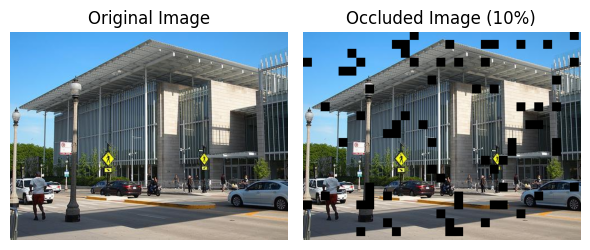

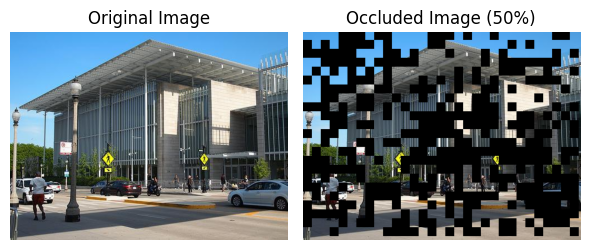

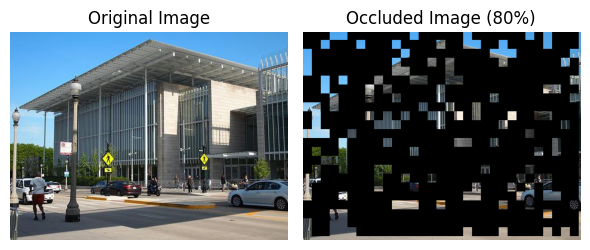

In [ ]:
path = "/kaggle/input/captioning/test/test_1.jpg"
image = Image.open(path).convert("RGB")
img = np.array(image)

img1 = occlude_image(img, 10)
img2 = occlude_image(img, 50)
img3 = occlude_image(img, 80)

visualize_occlusion(img, img1, 10)
visualize_occlusion(img, img2, 50)
visualize_occlusion(img, img3, 80)

#### **Generate captions using SmolVLM**

In [ ]:
def zero_shot_captioning(image_path, model_name="HuggingFaceTB/SmolVLM-Instruct") -> str:
    # Set device
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load processor and model
    processor = AutoProcessor.from_pretrained(model_name)
    processor.tokenizer.padding_side = "left"
    model = AutoModelForVision2Seq.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        attn_implementation="eager"
    )
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model = model.to(device)
    model.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")

    # First, prepare the chat template format without tokenizing
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Generate caption for this image."}
            ]
        }
    ]

    # Apply chat template to get the formatted text
    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
    )

    # Now process the formatted text and image together
    inputs = processor(
        text=prompt,
        images=[image],  # Note: images must be passed as a list
        return_tensors="pt",
        padding=True
    ).to(device)

    # Generate caption
    with torch.no_grad():
        if isinstance(model, nn.DataParallel):
            output = model.module.generate(**inputs, max_new_tokens=200)
        else:
            output = model.generate(**inputs, max_new_tokens=200)

    # Decode and return caption
    caption = processor.batch_decode(output, skip_special_tokens=True)[0]
    return caption

In [ ]:
occlusion_levels = [10]
hypotheses = {level: [] for level in occlusion_levels}
references = {level: [] for level in occlusion_levels}
filenames = {level: [] for level in occlusion_levels}

for level in occlusion_levels:
    folder_path = f"/content/occlusion_{level}"
    os.makedirs(folder_path, exist_ok=True)


def occlude_and_save(img, original_path, level):
    # Create occluded image
    occluded_img = occlude_image(img, level)

    # Save to writable directory
    base_name = os.path.basename(original_path).replace(".jpg", f"_occ_{level}.jpg")
    save_path = f"/content/occlusion_{level}/{base_name}"
    Image.fromarray(occluded_img).save(save_path)
    return save_path

In [ ]:
from pathlib import Path

total_images = len(test_dataset)
for idx in range(total_images):
    image_path, caption = test_dataset[idx]
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    image_filename = Path(image_path).name

    for occ in occlusion_levels:
        occluded_image_path = occlude_and_save(img_np, image_path, occ)

        # Generate caption
        generated_caption = zero_shot_captioning(occluded_image_path)
        generated_caption = generated_caption.replace("User:<image>Generate caption for this image.", "").strip()
        generated_caption = generated_caption.replace("Assistant:", "").strip()

        # Store captions
        hypotheses[occ].append(generated_caption)
        references[occ].append([caption.split()])
        filenames[occ].append(image_filename)

        # Optional preview print
        preview = " ".join(generated_caption.split()[:15])
        print(f"[{idx + 1}/{total_images}] Occlusion {occ}%: {preview}...")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.48k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.45k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

[1/928] Occlusion 10%: A large modern building with a flat roof and large windows is in the background....
[2/928] Occlusion 10%: A skier is skiing down a slope....
[3/928] Occlusion 10%: A bedroom with a stone floor and a yellow bed....
[4/928] Occlusion 10%: A black and white photo of a steam engine train passing through a station....
[5/928] Occlusion 10%: A yellow and white bus is parked in front of a store called Preterre....
[6/928] Occlusion 10%: A house with a black roof and white walls is in the middle of a...
[7/928] Occlusion 10%: Man playing wii with wii remote and nintendo controller....
[8/928] Occlusion 10%: Two cyclists riding on a street with a fire hydrant in the foreground....
[9/928] Occlusion 10%: A black phone with a knife and a black phone with a black background....
[10/928] Occlusion 10%: A black top hat sits on a mannequin head next to a clock....
[11/928] Occlusion 10%: A yellow and white train is parked at a station....
[12/928] Occlusion 10%: A man is bathi

In [ ]:
occlusion_levels = [50,80]
hypotheses = {level: [] for level in occlusion_levels}
references = {level: [] for level in occlusion_levels}
filenames = {level: [] for level in occlusion_levels}

for level in occlusion_levels:
    folder_path = f"/kaggle/working/occlusion_{level}"
    os.makedirs(folder_path, exist_ok=True)


def occlude_and_save(img, original_path, level):
    # Create occluded image
    occluded_img = occlude_image(img, level)

    # Save to writable directory
    base_name = os.path.basename(original_path).replace(".jpg", f"_occ_{level}.jpg")
    save_path = f"/kaggle/working/occlusion_{level}/{base_name}"

    Image.fromarray(occluded_img).save(save_path)
    return save_path

In [ ]:
from pathlib import Path

total_images = len(test_dataset)
for idx in range(total_images):
    image_path, caption = test_dataset[idx]
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    image_filename = Path(image_path).name

    for occ in occlusion_levels:
        occluded_image_path = occlude_and_save(img_np, image_path, occ)

        # Generate caption
        generated_caption = zero_shot_captioning(occluded_image_path)
        generated_caption = generated_caption.replace("User:<image>Generate caption for this image.", "").strip()
        generated_caption = generated_caption.replace("Assistant:", "").strip()

        # Store captions
        hypotheses[occ].append(generated_caption)
        references[occ].append([caption.split()])
        filenames[occ].append(image_filename)

        # Optional preview print
        preview = " ".join(generated_caption.split()[:15])
        print(f"[{idx + 1}/{total_images}] Occlusion {occ}%: {preview}...")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.48k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.45k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

[1/928] Occlusion 50%: A large modern building with a glass front is in the background. There are several...
[1/928] Occlusion 80%: A black and white photo of a street with a yellow sign in the middle....
[2/928] Occlusion 50%: A skier is jumping off a snowy mountain....
[2/928] Occlusion 80%: A black background with blue and white squares scattered throughout....
[3/928] Occlusion 50%: A bedroom with a large window and a door....
[3/928] Occlusion 80%: A black and white photo of a room with a large window and a door....
[4/928] Occlusion 50%: A train is on a track next to a bus....
[4/928] Occlusion 80%: Black background with many small squares in it....
[5/928] Occlusion 50%: A bus is parked in front of a store....
[5/928] Occlusion 80%: A collection of squares of different sizes and colors....
[6/928] Occlusion 50%: A sheep is grazing in the front yard of a house....
[6/928] Occlusion 80%: A black metal fence with squares of different sizes and colors....
[7/928] Occlusion 50%: A wo

In [ ]:
save_dir = "/kaggle/working/hypotheses_csv"
os.makedirs(save_dir, exist_ok=True)

for occ in occlusion_levels:
    df = pd.DataFrame({
        "filename": filenames[occ],
        "caption": hypotheses[occ]
    })
    csv_path = os.path.join(save_dir, f"hypotheses_occlusion_{occ}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")


Saved: /kaggle/working/hypotheses_csv/hypotheses_occlusion_50.csv
Saved: /kaggle/working/hypotheses_csv/hypotheses_occlusion_80.csv


#### **Evaluation Metrics [ SmolVLM ]**

In [3]:
!pip install evaluate
!pip install rouge
!pip install rouge_score
!pip install bert_score

In [4]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from rouge import Rouge
from bert_score import score

In [5]:
# #Neeed in kaggle for meteor score not needed in collab
# import zipfile
# nltk.data.path.append("/kaggle/working/nltk_data")  # Set the path
nltk.download('wordnet')
nltk.download('omw-1.4')
# zip_path = "/kaggle/working/nltk_data/corpora/wordnet.zip"
# extract_to = "nltk_data/corpora"

# # Make sure the target directory exists
# os.makedirs(extract_to, exist_ok=True)

# # Extract the zip file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# print("wordnet.zip extracted successfully.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:

'''
Function: performance_metrics
    Calculates and visualizes various evaluation metrics for comparing generated captions (hypotheses)
    with ground truth captions (references).

    The function computes BLEU, ROUGE-L, BERTScore and METEOR

Parameters:
    hypotheses (list): Generated captions
    references (list): Ground truth captions
    csv_path (str): Path to save the per-caption scores

Returns:
    dict: Dictionary containing average scores for all evaluation metrics

Outputs:
    - Saves detailed per-caption scores to a CSV file
    - Displays plots showing the distribution of scores across all captions
    - Prints aggregate metrics
'''

def performance_metrics(hypotheses, references, csv_path="caption_scores.csv"):
    hypotheses = [str(h).strip() if isinstance(h, (str, float)) else "" for h in hypotheses]
    references = [str(r).strip() if isinstance(r, (str, float)) else "" for r in references]

    smooth_fn = SmoothingFunction().method1

    sentence_bleu_scores = []
    rouge_l_scores = []
    bert_f1_scores = []
    meteor_scores_list = []
    rows = []

    rouge_evaluator = Rouge(metrics=["rouge-l"])
    _, _, bert_f1 = score(hypotheses, references, lang="en", verbose=False)
    bert_f1 = bert_f1.tolist()
    n = len(hypotheses)

    print("\n--- Caption Evaluation ---\n")

    for idx, (hypothesis, reference) in enumerate(zip(hypotheses, references)):
        if not hypothesis or not reference:
            bleu = rouge = meteor = 0
        else:
            bleu = sentence_bleu([reference.split()], hypothesis.split(), smoothing_function=smooth_fn)
            rouge = rouge_evaluator.get_scores([hypothesis], [reference])[0]["rouge-l"]["f"]
            meteor = meteor_score([reference.split()], hypothesis.split())

        sentence_bleu_scores.append(bleu)
        rouge_l_scores.append(rouge)
        meteor_scores_list.append(meteor)

        row = {
            "Index": idx + 1,
            "Hypothesis": hypothesis,
            "Reference": reference,
            "Sentence BLEU": bleu,
            "ROUGE-L F1": rouge,
            "BERTScore F1": bert_f1[idx],
            "METEOR": meteor
        }
        rows.append(row)
        #print(f"[{idx+1}/{n}] BLEU: {bleu:.4f}, ROUGE-L: {rouge:.4f}, BERT: {bert_f1[idx]:.4f}, METEOR: {meteor:.4f}")

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)

    indices = list(range(len(hypotheses)))
    step = max(len(hypotheses) // 20, 1)
    x_ticks = np.arange(0, len(hypotheses), step)

    fig, axs = plt.subplots(2, 2, figsize=(18, 8))

    axs[0, 0].plot(indices, sentence_bleu_scores, color='skyblue', linewidth=0.8)
    axs[0, 0].set_title("Sentence BLEU Score")
    axs[0, 0].set_xticks(x_ticks)
    axs[0, 0].set_xlabel("Caption Index")
    axs[0, 0].set_ylabel("Score")

    axs[0, 1].plot(indices, rouge_l_scores, color='salmon', linewidth=0.8)
    axs[0, 1].set_title("ROUGE-L F1 Score")
    axs[0, 1].set_xticks(x_ticks)
    axs[0, 1].set_xlabel("Caption Index")

    axs[1, 0].plot(indices, bert_f1, color='lightgreen', linewidth=0.8)
    axs[1, 0].set_title("BERTScore F1")
    axs[1, 0].set_xticks(x_ticks)
    axs[1, 0].set_xlabel("Caption Index")

    axs[1, 1].plot(indices, meteor_scores_list, color='violet', linewidth=0.8)
    axs[1, 1].set_title("METEOR Score")
    axs[1, 1].set_xticks(x_ticks)
    axs[1, 1].set_xlabel("Caption Index")

    plt.tight_layout()
    plt.show()

    results = {
        "Sentence BLEU Score": sum(sentence_bleu_scores) / len(sentence_bleu_scores) if sentence_bleu_scores else 0,
        "Corpus BLEU Score": corpus_bleu([[r.split()] for r in references if r], [c.split() for c in hypotheses if c]) if any(references) else 0,
        "Average ROUGE-L F1": sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0,
        "Average BERTScore F1": sum(bert_f1) / len(bert_f1) if bert_f1 else 0,
        "Average METEOR Score": sum(meteor_scores_list) / len(meteor_scores_list) if meteor_scores_list else 0
    }

    return results

#### Occlusion = 10%

In [9]:
hypotheses_file_path = '/content/hypotheses_occlusion_10.csv' # modify this based on collab or kaggle environment
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

928
928
A large modern building with a flat roof and large windows is in the background. The building is made of stone and has a modern design. In front of the building is a parking lot with a few cars parked. There are also a few people walking around.
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



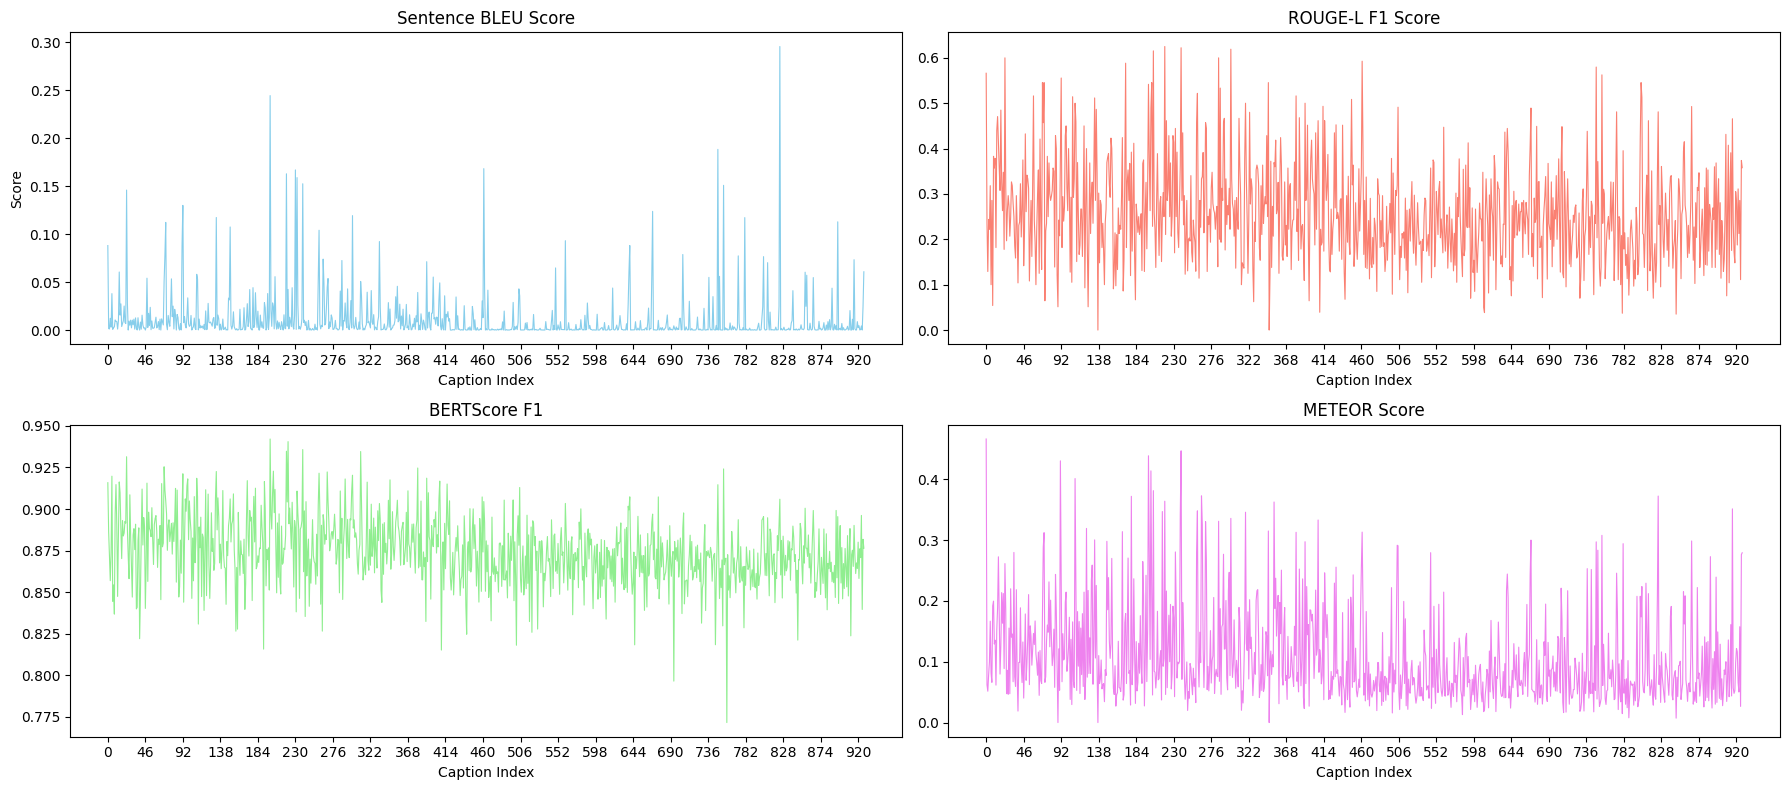

Performance Metrics:
Sentence BLEU Score: 0.0108
Corpus BLEU Score: 0.0080
Average ROUGE-L F1: 0.2579
Average BERTScore F1: 0.8744
Average METEOR Score: 0.1074


In [10]:
csv_path = 'smolvlm-scores_occlusion_10.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

#### Occlusion = 50%

In [11]:
hypotheses_file_path = '/content/hypotheses_occlusion_50.csv' # modify this based on collab or kaggle environment
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

928
928
A large modern building with a glass front is in the background. There are several cars parked in front of the building. There are a few people walking in front of the building.
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



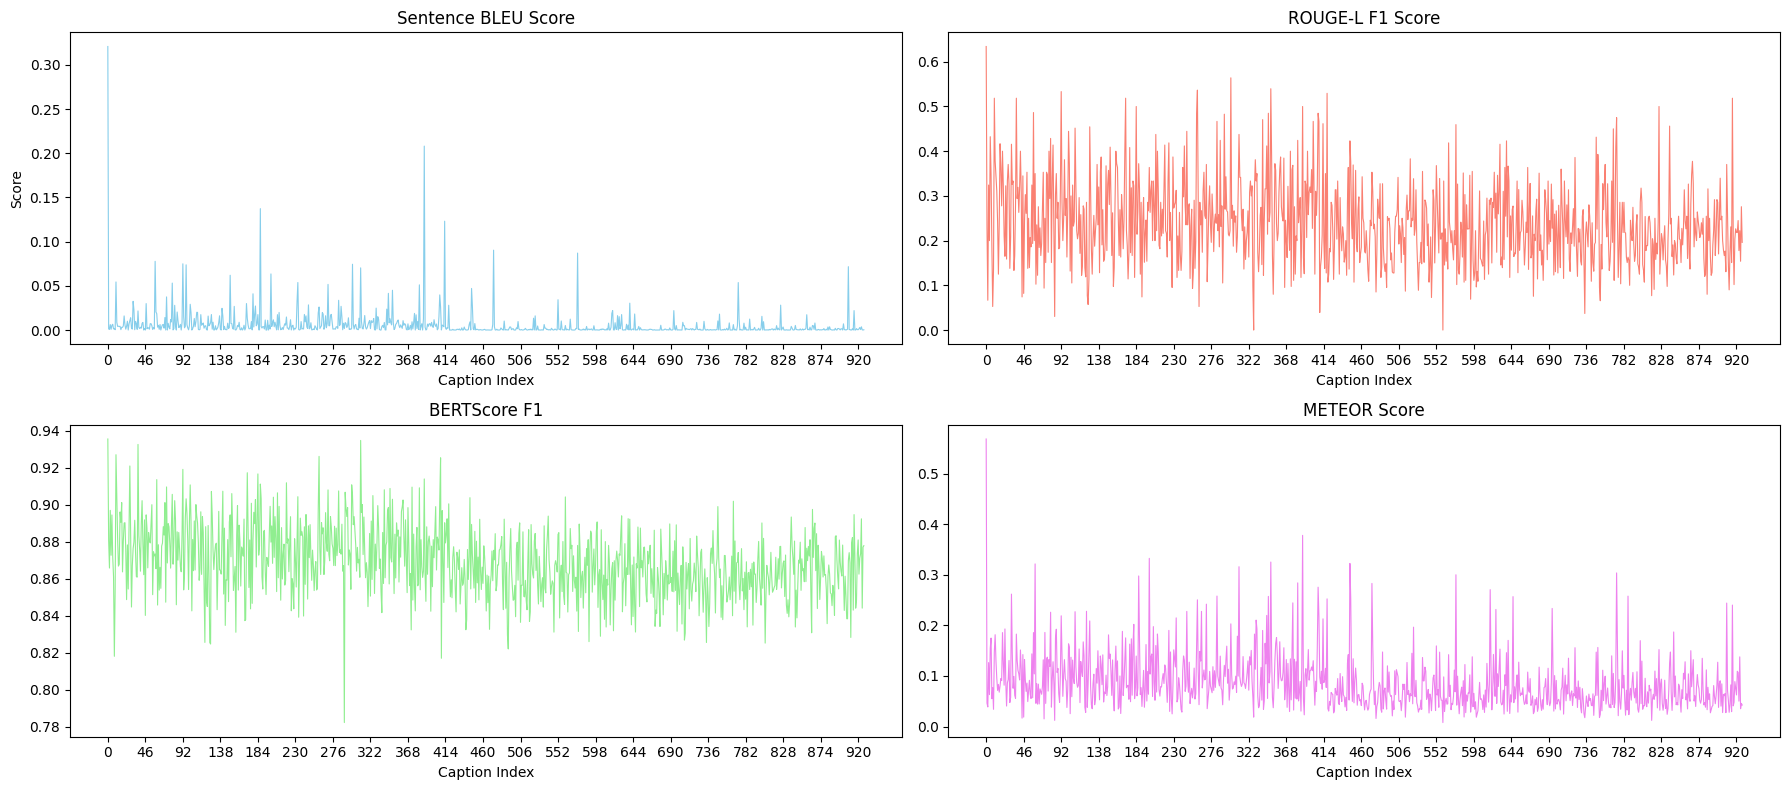

Performance Metrics:
Sentence BLEU Score: 0.0059
Corpus BLEU Score: 0.0031
Average ROUGE-L F1: 0.2393
Average BERTScore F1: 0.8687
Average METEOR Score: 0.0872


In [12]:
csv_path = 'smolvlm-scores_occlusion_50.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

#### Occlusion = 80%

In [13]:
hypotheses_file_path = '/content/hypotheses_occlusion_80.csv' # modify this based on collab or kaggle environment
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

928
928
A black and white photo of a street with a yellow sign in the middle.
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



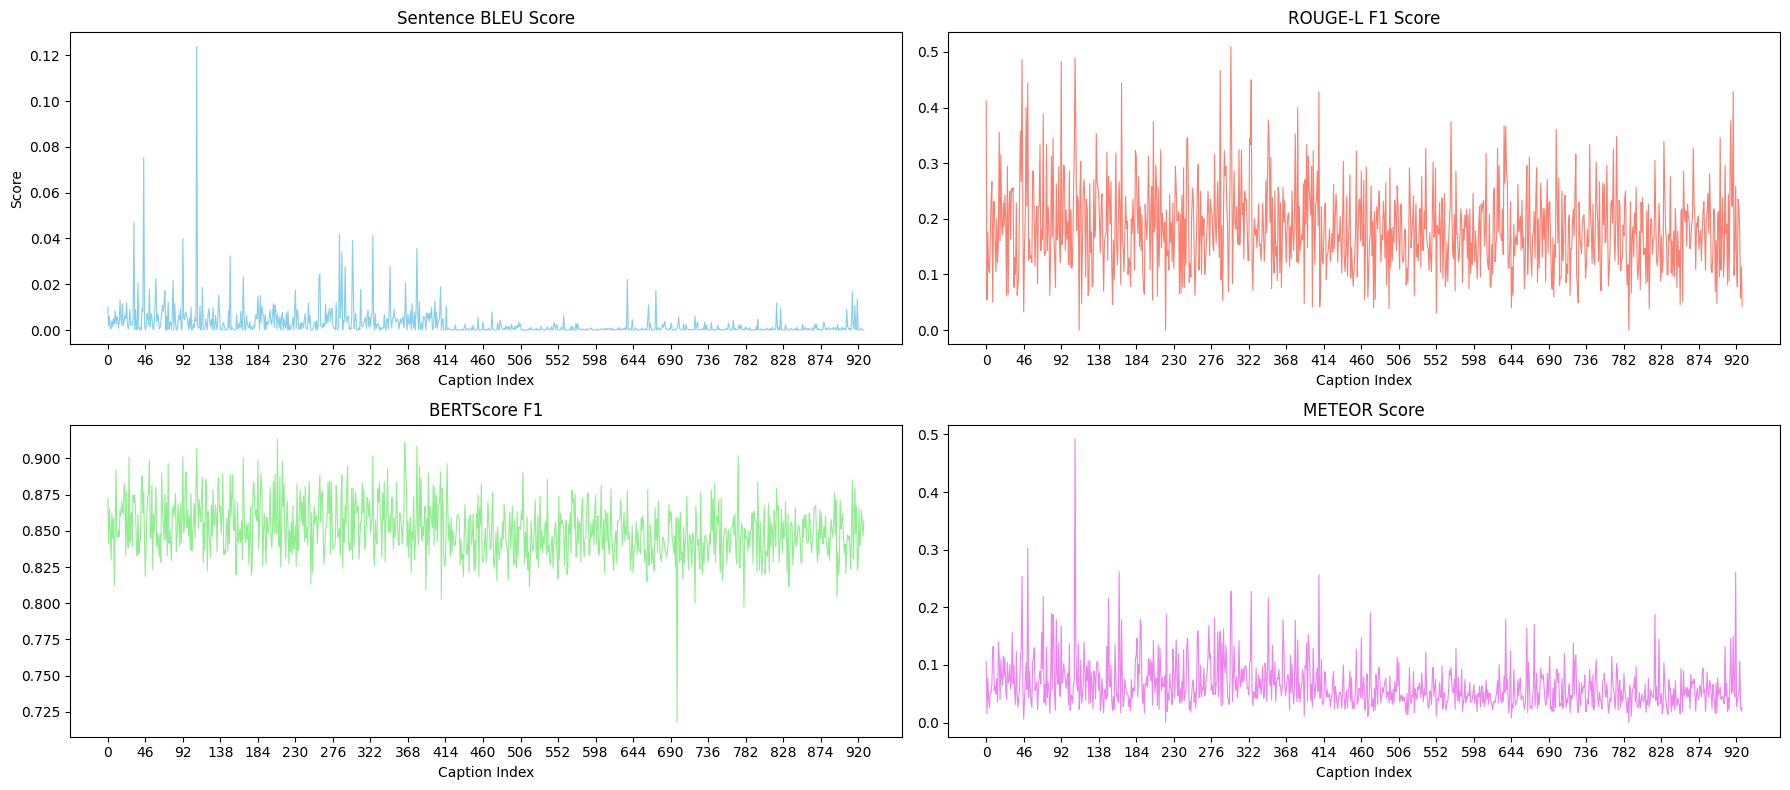

Performance Metrics:
Sentence BLEU Score: 0.0029
Corpus BLEU Score: 0.0010
Average ROUGE-L F1: 0.1835
Average BERTScore F1: 0.8510
Average METEOR Score: 0.0649


In [14]:
csv_path = 'smolvlm-scores_occlusion_80.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")